In [1]:
%%capture
!pip install facenet-pytorch

## Libaries

In [2]:
import sys
sys.path.append('/home/pj00/projects/Github/small_face_recognition_trcking/utils')

In [3]:
from facenet_pytorch import MTCNN, InceptionResnetV1, fixed_image_standardization
import torch
from torchvision import datasets, transforms
import cv2
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
import time
import os
from utils import model_size, detect_crop_image
from custom_model import distill_model
import torch.nn as nn
from utils import extract_face, take_picture, detect_crop_image, next_folder_name, aug_img, create_neg_class, model_size
from torch.nn.functional import cosine_similarity
from image_iter import FaceDataset, customSubset
from PIL import Image
from torchvision.transforms.functional import to_pil_image, pil_to_tensor

/home/pj00/anaconda3/envs/CVenv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Functions

In [4]:
def extract_faces(frame):
    # Convert frame from BGR to RGB (OpenCV uses BGR by default)
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
    # Detect faces
    boxes, _ = mtcnn.detect(rgb_frame)
    
    faces = []
    if boxes is not None:
        for box in boxes:
            x1, y1, x2, y2 = map(int, box)
            face = frame[y1:y2, x1:x2]
            faces.append((face, x1, y1, x2, y2))
    
    return faces

In [5]:
def create_class_data(data_folder, num_classes, num_images, aug_transform, dataset, idx_dict, model, crop_transform, device):
    class_path = []

    if num_classes == 1:
        path = os.path.join(data_folder, '{}'.format(next_folder_name(data_folder)))
        class_path.append(path)
        try:
            os.mkdir(path)
        except:
            print('Path exists: Issue!')
        create_neg_class(path, num_images, aug_transform, dataset, idx_dict) # add 50 random images

        frame, save_path = extract_face(save_path=data_folder)
        class_path.append(save_path)
        save_path = os.path.join(save_path, '0.jpg')
        images = detect_crop_image(frame=frame, model=mtcnn, transform=crop_transform, device=device)
        pil_image = to_pil_image(images[0].detach().cpu())
        pil_image.save(save_path)
        aug_img(save_path=save_path, transform=aug_transform, num_images=num_images)

    else:
        for i in range(num_classes-1):
            path = os.path.join(data_folder, '{}'.format(next_folder_name(data_folder)))
            class_path.append(path)
            try:
                os.mkdir(path)
            except:
                print('Path exists: Issue!')
            create_neg_class(path, num_images, aug_transform, dataset, idx_dict, key=i) # add 50 random images
        
        frame, save_path = extract_face(save_path=data_folder)
        class_path.append(save_path)
        save_path = os.path.join(save_path, '0.jpg')
        images = detect_crop_image(frame=frame, model=mtcnn, transform=crop_transform, device=device)
        pil_image = to_pil_image(images[0].detach().cpu())
        pil_image.save(save_path)
        aug_img(save_path=save_path, transform=aug_transform, num_images=num_images)
        
    return class_path

In [6]:
data_folder = '/home/pj00/projects/Github/small_face_recognition_trcking/Data/embedding_data'
train_root = '/home/pj00/projects/Github/small_face_recognition_trcking/Data/CASIA/casia-webface/train.rec'

In [7]:
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((112, 112)),
    transforms.ToTensor()
])

In [8]:
crop_transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor()
])

In [9]:
no_transform = transforms.Compose([
    transforms.ToTensor(),    
    transforms.ToPILImage()
])

## Models

In [10]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
# device='cpu'

In [11]:
mtcnn = MTCNN(
    image_size=112,
    margin=0,
    min_face_size=20,
    thresholds=[0.6, 0.7, 0.7],
    factor=0.709,
    post_process=False,
    device=device
)

In [12]:
resnet_class = InceptionResnetV1(
    classify=True,
    pretrained='casia-webface',
    num_classes=2
).to(device)

weight_path = '/home/pj00/projects/Github/small_face_recognition_trcking/model-weights/finetuned/resnet/resnet_adam_8.pt'
resnet_class.load_state_dict(torch.load(weight_path))


print('Done')
model_size(resnet_class)

Done
model size: 751476800 / bit | 93.93 / MB


In [13]:
teacher = InceptionResnetV1(pretrained='casia-webface').to(device)

model_size(teacher)

model size: 925043168 / bit | 115.63 / MB


In [14]:
student = distill_model().to(device)
student_class = nn.Sequential(student, nn.Hardswish(), nn.Dropout(p=0.2, inplace=True), nn.Linear(512, 2))
student_class.to(device)

weight_path = '/home/pj00/projects/Github/small_face_recognition_trcking/model-weights/finetuned/mobV3/mobV3_sgd_8.pt'
student_class.load_state_dict(torch.load(weight_path))


print('Done')
model_size(student_class)

Done
model size: 65397824 / bit | 8.17 / MB


/home/pj00/anaconda3/envs/CVenv/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/pj00/anaconda3/envs/CVenv/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Small_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [15]:
student = distill_model().to(device)
weight_path = '/home/pj00/projects/Github/small_face_recognition_trcking/model-weights/mobV3_adam_29.pt'
student.load_state_dict(torch.load(weight_path))
model_size(student)

model size: 65364992 / bit | 8.17 / MB


## Create dataset

In [16]:
data_path = '/home/pj00/projects/Github/small_face_recognition_trcking/Data/embedding_data'
train_root = '/home/pj00/projects/Github/small_face_recognition_trcking/Data/CASIA/casia-webface/train.rec'

In [17]:
dataset = FaceDataset(path_imgrec=train_root, rand_mirror=True)
ss = customSubset(train_root)
idx_dict = ss.generate_idx_dic()

/home/pj00/projects/Github/small_face_recognition_trcking/Data/CASIA/casia-webface/train.rec /home/pj00/projects/Github/small_face_recognition_trcking/Data/CASIA/casia-webface/train.idx
header0 label [490624. 501196.]
id2range 10572


In [18]:
class_paths = create_class_data(data_folder=data_path, 
                                num_classes=100, 
                                num_images=1, 
                                aug_transform=no_transform, 
                                dataset=dataset, 
                                idx_dict=idx_dict, 
                                model=mtcnn, 
                                crop_transform=crop_transform, 
                                device=device)

[ WARN:0@19.026] global /croot/opencv-suite_1691620365762/work/modules/videoio/src/cap_gstreamer.cpp (862) isPipelinePlaying OpenCV | GStreamer warning: GStreamer: pipeline have not been created
libGL error: MESA-LOADER: failed to open iris: /usr/lib/dri/iris_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)
libGL error: failed to load driver: iris
libGL error: MESA-LOADER: failed to open iris: /usr/lib/dri/iris_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)
libGL error: failed to load driver: iris
libGL error: MESA-LOADER: failed to open swrast: /usr/lib/dri/swrast_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)
libGL error: failed to load driver: swrast


Photo taken!


### Create embeddings

In [19]:
teacher_embeds = []
teacher.eval()
for class_path in class_paths:
    x = Image.open(os.path.join(class_paths, '0.jpg'))
    xx = pil_to_tensor(x)
    xxxx = xx.to(device, dtype=torch.float32)
    xxxxx = torch.unsqueeze(xxxx, axis=0)
    with torch.no_grad():
        y = teacher(xxxxx)
    teacher_embeds.append(torch.squeeze(y))
teahcer_embeds = torch.stack(teacher_embeds)

TypeError: expected str, bytes or os.PathLike object, not list

In [ ]:
student_embeds = []
student.eval()
for class_path in class_paths:
    x = Image.open(os.path.join(class_path, '0.jpg'))
    xx = pil_to_tensor(x)
    xxxx = xx.to(device, dtype=torch.float32)
    xxxxx = torch.unsqueeze(xxxx, axis=0)
    with torch.no_grad():
        y = student(xxxxx)
    student_embeds.append(torch.squeeze(y))
student_embeds = torch.stack(student_embeds)

In [20]:
cap = cv2.VideoCapture(0)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print(width, height)
ret, frame = cap.read()

[ WARN:0@26.223] global /croot/opencv-suite_1691620365762/work/modules/videoio/src/cap_gstreamer.cpp (862) isPipelinePlaying OpenCV | GStreamer warning: GStreamer: pipeline have not been created


640 480


In [21]:
frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

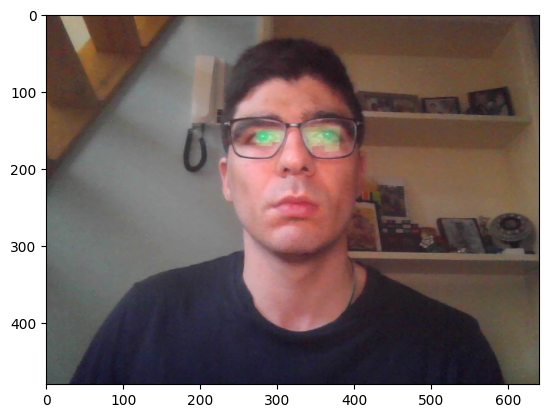

In [22]:
plt.imshow(frame)

In [23]:
face_data = extract_faces(frame)
faces, x1, y1, x2, y2 = face_data[0]
face_tr = torch.unsqueeze(transform(faces), axis=0)

In [24]:
zz = torch.squeeze(face_tr)

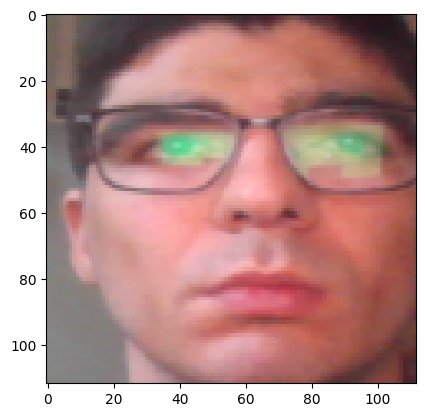

In [25]:
plt.imshow(zz.permute(1,2,0))

In [27]:
# y = teacher(face_tr.to(device))
# single_vector = y.unsqueeze(0)

# if torch.argmax(cosine_similarities).detach().cpu() == 99:
#     color = (0, 255, 0)
#     thickness = 2
#     cv2.rectangle(frame, (x1, y1), (x2, y2), color, thickness)
#     print('found')

# else:
#     color = (0, 0, 255)
#     thickness = 2
#     cv2.rectangle(frame, (x1, y1), (x2, y2), color, thickness)

## Face detection

In [31]:
cap = cv2.VideoCapture(0)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print(width, height)

640 480


[ WARN:0@52.804] global /croot/opencv-suite_1691620365762/work/modules/videoio/src/cap_gstreamer.cpp (862) isPipelinePlaying OpenCV | GStreamer warning: GStreamer: pipeline have not been created


In [32]:
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((112, 112)),
    transforms.ToTensor()
])

In [34]:
prev_frame_time = 0
new_frame_time = 0
font = cv2.FONT_HERSHEY_SIMPLEX 

start = time.time()
frame_counter = 0

student_class.eval()
resnet_class.eval()


while True:
    ret, frame = cap.read()
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    frame_counter += 1
    
    face_data = extract_faces(frame)
    faces, x1, y1, x2, y2 = face_data[0]
    face_tr = torch.unsqueeze(transform(faces), axis=0)
    
    with torch.no_grad():
        y = resnet_class(face_tr.to(device))
        
#     single_vector = y.unsqueeze(0)
    
    if torch.argmax(y).detach().cpu() == 1:
        color = (0, 255, 0)
        thickness = 2
        cv2.rectangle(frame, (x1, y1), (x2, y2), color, thickness)
    
    else:
        color = (0, 0, 255)
        thickness = 2
        cv2.rectangle(frame, (x1, y1), (x2, y2), color, thickness)
    
    # Exit if ESC pressed
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break    
    
    frame_counter += 1
    new_frame_time = time.time()
    fps = 1/(new_frame_time-prev_frame_time) 
    prev_frame_time = new_frame_time 
    fps = int(fps) 
    fps = str(fps) 
    
    cv2.putText(frame, fps, (7, 70), font, 3, (100, 255, 0), 3, cv2.LINE_AA) 
    
    cv2.imshow('frame', frame)
    
cv2.waitKey(0)
cv2.destroyAllWindows()


end = time.time()

print('FPS: {:.2f}'.format(frame_counter/(end-start)))

FPS: 40.38
